<a href="https://colab.research.google.com/github/yiqi0806-collab/Sensitive-annlysis/blob/main/global_activity_scores_gaussian_quad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#### GAS gaussian-quad 旧版"错误"代码
import numpy as np
import numpy.random as R
import time
from scipy.stats import qmc
from scipy.stats import norm
from scipy.stats import chi2
from scipy import stats
from typing import Callable
from scipy.integrate import newton_cotes
from scipy.special import roots_legendre
import random
import math
import matplotlib.pyplot as plt
from numpy.linalg import eig
%matplotlib inline
from scipy.integrate import solve_ivp, simpson




NEWTON_COTES_POINTS = {
    1: np.array([1/2]),
    2: np.array([1/3, 2/3]),
    3: np.array([1/4, 2/4, 3/4]),
    4: np.array([1/5, 2/5, 3/5, 4/5]),
}

NEWTON_COTES_WEIGHTS = {
    1: np.array([1.0]),
    2: np.array([1/2, 1/2]),
    3: np.array([1/6, 4/6, 1/6]),
    4: np.array([1/8, 3/8, 3/8, 1/8]),
}

def get_newton_cotes_closed(n: int):
    if n < 1:
        raise ValueError("Order n must be at least 1.")
    elif n == 1:
        weights_integral = np.array([1.0])
    else:
        weights_integral, _ = newton_cotes(n-1)
    weights_average = weights_integral / sum(weights_integral)
    points = np.linspace(0, 1, n + 2)

    return points[1:-1], weights_average

def get_gauss_legendre(n: int):
    a = 0.0
    b = 1.0
    nodes_std, weights_std = roots_legendre(n)
    nodes_transformed = 0.5 * (b - a) * nodes_std + 0.5 * (a + b)
    weights_transformed = 0.5 * (b - a) * weights_std
    return nodes_transformed, weights_transformed

def calculate_finite_difference_matrix(
    f: Callable[[np.ndarray], np.ndarray],
    X: np.ndarray,
    n_points: int = 2
) -> np.ndarray:

    sample_len, dim = X.shape
    fd_matrix = np.zeros_like(X, dtype=float)
    f_value_old = f(X)

    #weights = NEWTON_COTES_WEIGHTS[n_points]
    #points = NEWTON_COTES_POINTS[n_points]
    points, weights = get_gauss_legendre(n_points)
    1+1
    for i in range(sample_len):
        for j in range(dim):
            eval_batch_left = np.tile(X[i, :], (n_points, 1))
            eval_batch_left[:, j] *= points
            f_values_left = f(eval_batch_left)
            x_left = (eval_batch_left[:, j] - np.tile(X[i, j], (n_points, 1))[0])
            y_left = (f_values_left - f_value_old[i])
            average_value_left = np.dot(y_left / x_left, weights)

            eval_batch_right = np.tile(X[i, :], (n_points, 1))
            eval_batch_right[:, j] = eval_batch_right[:, j] + points * (1 - eval_batch_right[:, j])
            f_values_right = f(eval_batch_right)
            x_right = (eval_batch_right[:, j] - np.tile(X[i, j], (n_points, 1))[0])
            y_right = (f_values_right - f_value_old[i])
            average_value_right = np.dot(y_right / x_right, weights)

            fd_matrix[i, j] = average_value_left * X[i, j] + average_value_right * (1-X[i, j])
            #print(j, eval_batch_left, eval_batch_right)
    return fd_matrix

if __name__ == '__main__':
    def f_test(x: np.ndarray) -> np.ndarray:
        x1 = x[:, 0]
        x2 = x[:, 1]
        return x1 + 2 * x2

    X_test = np.array([
        [0.1, 0.2],
        [0.5, 0.3],
        [0.8, 0.4]
    ])

    # --- Run the numerical calculation with different n_points ---
    for points in [4,10]:
        print(f"--- Calculating with n_points = {points} ---")
        fd_result = calculate_finite_difference_matrix(
            f=f_test,
            X=X_test,
            n_points=points
        )
        print(f"Resulting finite difference matrix:\n{fd_result}\n")

    print("Note:")
    print("The 2-point rule is exact for the second dimension because f is linear in x2.")
    print("The 3-point rule (Milne's) is exact for polynomials of degree 3 or less, so it is exact for x1^2.")

def dFunc0(x,Func,M2,shiftedSobol=True,distribution='uniform'):    #rememebr to change distribution if not use shiftedSobol
    chi,dim = x.shape[0],x.shape[1]
    temp = np.zeros((dim,chi*M2))
    #print("55555",x)
    if(shiftedSobol == True):
        rand_add = qmc.Sobol(dim, scramble=False).random(M2+1)[1:]
        for i in range(M2):
            xe = np.tile(x.transpose(), dim).transpose()*(1-np.repeat(np.array(np.identity(dim)), chi, axis=0))
            if distribution == 'normal':
                rand = norm.ppf((norm.cdf(x)+rand_add[i])%1)
            elif distribution == 'uniform':
                rand = (x+rand_add[i])%1
            elif distribution =='chi_squared':
                rand1 = chi2.ppf((chi2.cdf(x[:,0],df=10)+rand_add[i][0])%1, df=10)
                rand2 = chi2.ppf((chi2.cdf(x[:,1],df=13.978)+rand_add[i][1])%1, df=13.978)
                rand = np.column_stack((rand1, rand2))
            #print("22222",rand)
            xe += rand.T.reshape(dim*chi,1)*np.repeat(np.array(np.identity(dim)), chi, axis=0)
            #print("11111",xe)
            #xe += rand.T * np.repeat(np.array(np.identity(dim)), chi, axis=0)
            #print("55555",x.shape)
            #print("66666",Func(xe).shape)
            #print("77777",Func(x).shape)
            #print("8888",np.tile(Func(x),dim).shape)
            #print("101010",np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1).reshape(dim,chi))
            temp[:,i*(chi):(i+1)*(chi)] = ((Func(xe)-np.tile(Func(x),dim))/np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1)).reshape(dim,chi)

    else:
        for i in range(M2):
            xe = np.tile(x.transpose(), dim).transpose()*(1-np.repeat(np.array(np.identity(dim)), chi, axis=0))
            if distribution == 'normal':
                rand = R.normal(0,1,(chi,dim))
            elif distribution == 'uniform':
                rand = R.uniform(0,1,(chi,dim))
            xe += rand.T.reshape(dim*chi,1)*np.repeat(np.array(np.identity(dim)), chi, axis=0)
            temp[:,i*(chi):(i+1)*(chi)] = ((Func(xe)-np.tile(Func(x),dim))/np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1)).reshape(dim,chi)

    return temp

# Calculate eigenvalue decomposition //Func in put is m*n matrix, where n is the dimension of x of f(x), m is how many sample to repeat for x 比如100*10 100个x 每个x是10dimension.
#                     output is m number of result f(x)
def GAS(Func,dim,chi,M1,M2,shiftedSobol=True,distribution='uniform'):      #remember to change distribution
    if distribution == 'normal':
        z = R.normal(0, 1, (M1, dim))
    elif distribution == 'uniform':
        z = R.uniform(0, 1, (M1, dim))
        #for i, parameters in enumerate(z):
          #a=solve_and_integrate(parameters,10)
          #while a<28402714.35 or a>276499908.09:
            #z[i] = R.uniform(0, 1, (1, dim))
            #a=solve_and_integrate(parameters,10)
    elif distribution == 'chi_squared':                 #special case for chi_squared
        x1_samples = R.chisquare(df=10, size=M1)
        x2_samples = R.chisquare(df=13.978, size=M1)
        z = np.column_stack((x1_samples, x2_samples))
    deriv = dFunc0(z,Func,M2,shiftedSobol,distribution=distribution)
    deriv /= np.sqrt(chi)
    u, s, vh = np.linalg.svd(deriv.astype(float), full_matrices=True)
    s = s**2
    return u, s



# Estimate the matrix Phi
def Phi_est(X, expo, coef, P):
    Num = X.shape[0]
    dim = X.shape[1]
    return np.dot(np.prod((np.tile(X, P)**expo.flatten()).reshape((Num*P, dim)),axis = 1).reshape((Num, P))
               ,np.array(coef)).T

def Funy(z,z1,u,Func):
    dim = u.shape[0]
    dim1 = z.shape[1]
    chi = z.shape[0]
    f1 = Func(np.dot(z,u[:,:dim1].transpose())+np.dot(z1,u[:,dim1:].transpose()))
    return f1

# Estimate k hat
def estimate_k_reg1(z,z1,u, exponents, coefficients, P, Func):
    phi = Phi_est(z, exponents, coefficients,P)
    khat = np.linalg.inv(phi @ np.transpose(phi)) @ phi @ Funy(z,z1,u,Func)
    return khat

# Estimate the expectation from PCE
def GAS_PCE(Func, Num_exp, z1, dim1, u, exponents, coefficients, P):
    PCE = np.zeros(Num_exp)
    for i in range(Num_exp):
        kii = estimate_k_reg1(z1[i][:,:dim1], z1[i][:,dim1:], u, exponents, coefficients, P, Func)
        PCE[i] = kii[0]
    return PCE

def GAS_score(m,u,s):                         #m is how many eigenvalue we use
  gas_score = u[:,:m]**2@s[:m]/sum(u[:,:m]**2@s[:m])
  return gas_score

def solve_and_integrate(parameters,n):
    K, p, mu, Rm, v, T, K_hat, r= parameters
    K=K*(1.3-0.7)*3.5+0.7*3.5
    p=p*(1.3-0.7)*2+0.7*2
    mu=mu*(1.3-0.7)*0.5+0.7*0.5
    Rm=Rm*(1.3-0.7)*1+0.7*1
    v=v*(1.3-0.7)*1+0.7*1
    T=T*(1.3-0.7)*5+0.7*5
    K_hat=K_hat*(1.3-0.7)*43+0.7*43
    r=r*(1.3-0.7)*0.7+0.7*0.7


    # Define the ODE systems
    def ode_system_1(t, B):
        return K * p / (mu * (Rm + v * B))

    def ode_system_2(t, B):
        return -K_hat * p * B / (mu * (Rm + v * B))

    # Initialize
    B0 = 0.0  # Initial condition for B
    total_integrand_values = []
    total_time_points = []
    B_values = []  # Store B values over time

    # Interval length
    interval_length = T / n

    for i in range(n):
        # Time spans for the current interval
        t1_span = (i * interval_length, i * interval_length + r * interval_length)
        t2_span = (i * interval_length + r * interval_length, (i + 1) * interval_length)

        # Solve first ODE in the current interval
        t1_eval = np.linspace(t1_span[0], t1_span[1], 50)
        solution_1 = solve_ivp(ode_system_1, t1_span, [B0], t_eval=t1_eval, method='RK45')
        t1 = solution_1.t
        B1 = solution_1.y[0]

        # Solve second ODE in the current interval
        B1_final = B1[-1]  # Final value of B from the first ODE
        t2_eval = np.linspace(t2_span[0], t2_span[1], 50)
        solution_2 = solve_ivp(ode_system_2, t2_span, [B1_final], t_eval=t2_eval, method='RK45')
        t2 = solution_2.t
        B2 = solution_2.y[0]

        # Combine time and B values for this interval
        t_combined = np.concatenate((t1, t2))
        B_combined = np.concatenate((B1, B2))

        # Update the initial condition for the next interval using the final state of B2
        B0 = B2[-1]

        # Store results
        total_time_points.extend(t_combined)
        B_values.extend(B_combined)

        # Compute the integrand values
        integrand_1 = p / (mu * (Rm + v * np.array(B1)))  # First part
        integrand_2 = -p / (mu * (Rm + v * np.array(B2))) # Second part (negative)

        total_integrand_values.extend(integrand_1)
        total_integrand_values.extend(integrand_2)

    # Compute the final integral
    integral_simps = simpson(total_integrand_values, x=total_time_points)

    # Compute cumulative integral approximation
    cumulative_integral = np.cumsum(np.array(total_integrand_values) * np.gradient(total_time_points))

    return cumulative_integral[-1]

def percentage_within_std_range(numbers, std_range=1):
    mean_val = np.mean(numbers)  # Compute the mean
    std_dev = np.std(numbers, ddof=1)  # Compute standard deviation

    # Define the statistical range
    lower_bound = mean_val - std_range * std_dev
    upper_bound = mean_val + std_range * std_dev

    # Count numbers within the range
    within_range = [num for num in numbers if lower_bound <= num <= upper_bound]
    percentage_within = (len(within_range) / len(numbers)) * 100

    return {
        "mean": mean_val,
        "std_dev": std_dev,
        "range": (lower_bound, upper_bound),
        "percentage_within": percentage_within,
        "total_values": len(numbers),
        "values_within_range": len(within_range)
    }


def Func(x):
  results = []
  for i, parameters in enumerate(x):
    #print("index is",i)
    results.append(solve_and_integrate(parameters,10))
  results = np.array(results)

    # Plot the results inside Func
  #plt.figure(figsize=(10, 5))
  #plt.plot(range(len(results)), results, marker='o', linestyle='-', color='b', label="Func Output")
  #plt.xlabel("Sample Index")
  #plt.ylabel("Function Output")
  #plt.title("Plot of Func(x) Output Values")
  #plt.legend()
  #plt.grid(True)
  #plt.show()

  #result = percentage_within_std_range(results, std_range=2)  # Using ±2 standard deviations (95%)

  ## Print results
  #print("Mean:", result["mean"])
  #print("Standard Deviation:", result["std_dev"])
  #print("Accepted Range:", result["range"])
  #print("Percentage Within Range:", result["percentage_within"], "%")
  return np.array(results)

--- Calculating with n_points = 4 ---
Resulting finite difference matrix:
[[1. 2.]
 [1. 2.]
 [1. 2.]]

--- Calculating with n_points = 10 ---
Resulting finite difference matrix:
[[1. 2.]
 [1. 2.]
 [1. 2.]]

Note:
The 2-point rule is exact for the second dimension because f is linear in x2.
The 3-point rule (Milne's) is exact for polynomials of degree 3 or less, so it is exact for x1^2.


55555 (500, 8)
Time: 3697.84680792 seconds


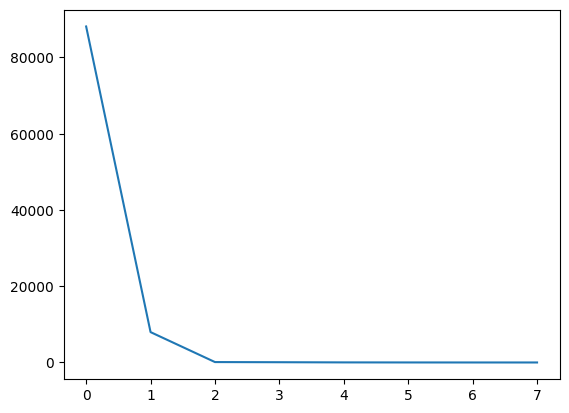

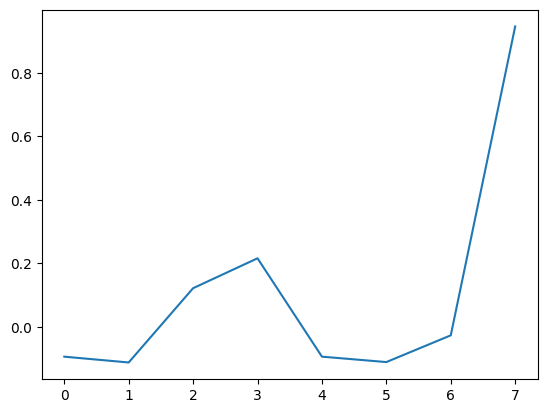

The parameter order is :K, p, mu, Rm, v, T, K_hat, r
GAS_score is [8.77501178e-03 1.25330837e-02 1.48803211e-02 4.67279505e-02
 8.76490935e-03 1.22505676e-02 7.02114534e-04 8.95366042e-01]
K is: 0.00877501177988561
p is: 0.012533083672025795
mu is: 0.014880321071758358
Rm is: 0.04672795046961713
v is: 0.00876490934871162
T is: 0.0122505675990356
K_hat is: 0.0007021145341226112
r is: 0.8953660415248433


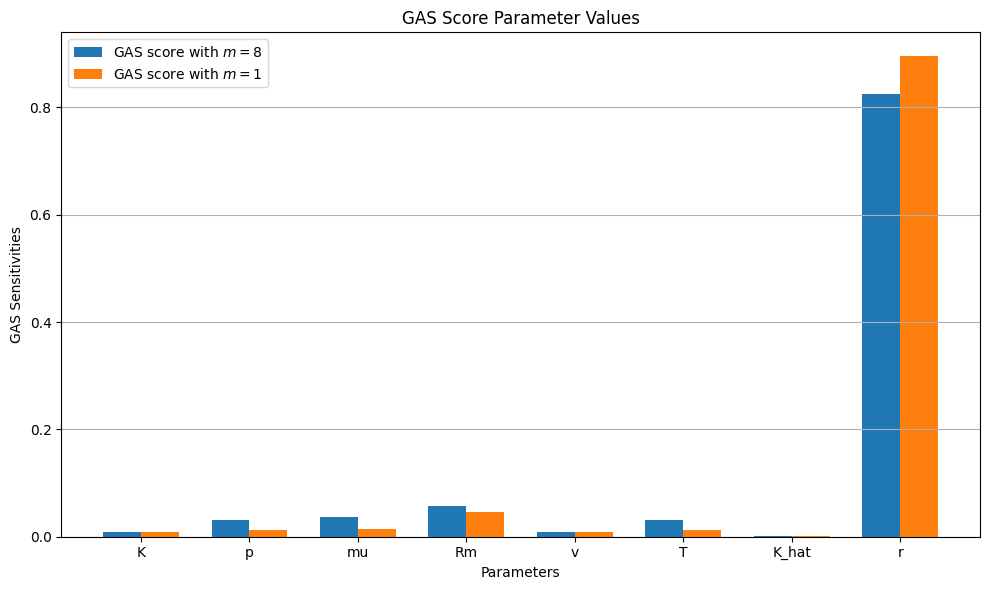

In [ ]:
start = time.perf_counter()
dim=8
chi=10000
M2 = 10
fd_result = calculate_finite_difference_matrix(
            f=Func,
            X=R.uniform(0, 1, (int(chi/2/M2), dim)),
            n_points=M2
        )
print("55555",fd_result.shape)
u, s, _ = np.linalg.svd(fd_result.T.astype(float), full_matrices=False)
s = s**2
gas_values8 = GAS_score(8, u, s)
gas_values = GAS_score(1, u, s)
end = time.perf_counter()
print("Time:", end - start, "seconds")


plt.plot(s)
plt.show()

plt.plot(u[:,0])
plt.show()

# Print the values
print("The parameter order is :K, p, mu, Rm, v, T, K_hat, r")
print("GAS_score is",gas_values)
print("K is:",gas_values[0])
print("p is:",gas_values[1])
print("mu is:",gas_values[2])
print("Rm is:",gas_values[3])
print("v is:",gas_values[4])
print("T is:",gas_values[5])
print("K_hat is:",gas_values[6])
print("r is:",gas_values[7])


# 参数标签
parameters = ["K", "p", "mu", "Rm", "v", "T", "K_hat", "r"]
x = np.arange(len(parameters))
width = 0.35

# 绘制并排柱状图
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, gas_values8, width, label=r'GAS score with $m=8$')
plt.bar(x + width/2, gas_values, width, label=r'GAS score with $m=1$')

# 设置标签和样式
plt.xlabel("Parameters")
plt.ylabel("GAS Sensitivities")
plt.title("GAS Score Parameter Values")
plt.xticks(x, parameters)
plt.grid(axis='y')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#### GAS gaussian-quad 新版更正代码
from typing import Callable, Optional
from scipy.special import roots_legendre
import numpy as np
import numpy.random as R
import time
from scipy.stats import qmc
from scipy.stats import norm
from scipy.stats import chi2
from scipy import stats
from scipy.integrate import newton_cotes
import random
import math
import matplotlib.pyplot as plt
from numpy.linalg import eig
%matplotlib inline
from scipy.integrate import solve_ivp, simpson

def _gauss_legendre_01(n: int):
    # GL on (0,1): map (-1,1) -> (0,1)
    t, w = roots_legendre(n)
    s = 0.5*(t + 1.0)     # nodes in (0,1)
    w = 0.5*w             # sum to 1
    return s, w

def calc_C(
    f: Callable[[np.ndarray], np.ndarray],
    X: np.ndarray,
    n_points: int = 10,
    g: Optional[Callable[[np.ndarray], np.ndarray]] = None,  # 边缘密度；均匀时可缺省
    return_AS: bool = False,  # 如需调试可顺带返回 A,S
    clip_eps: float = 1e-12   # 数值误差矫正
):
    """
    直接返回“正确的”敏感度矩阵 C（对称 PSD）：
      - 对角: E_z[ ∫ q_i(v;z)^2 dv ]
      - 非对角: E_z[ (∫ q_i dv)(∫ q_j dv) ]
    不增加任何 f 调用；只在同一批节点上额外做了平方与加权。
    """
    M, d = X.shape
    A = np.zeros((M, d), dtype=float)   # A[i,j] = ∫ q_i dv  （非对角用）
    S = np.zeros((M, d), dtype=float)   # S[i,j] = ∫ q_i^2 dv（对角用）

    s_nodes, s_w = _gauss_legendre_01(n_points)
    f_z = f(X)                          # 基点 f(z) 只算一次

    for i in range(M):
        z  = X[i]
        fz = f_z[i]

        for j in range(d):
            zj = z[j]

            # --- 左段 v ∈ [0, z_j],  v = z_j * s  ---
            if zj > 0.0:
                eval_left = np.tile(z, (n_points, 1))
                eval_left[:, j] = zj * s_nodes
                f_left = f(eval_left)                 # 复用：不重复算

                vL = eval_left[:, j]
                qL = (f_left - fz) / (vL - zj)        # q = (f(v)-f(z)) / (v - z_j)

                gL = 1.0 if g is None else g(vL)
                JL = zj                               # dv = z_j ds

                A[i, j] += np.dot(qL,        s_w) * JL * gL
                S[i, j] += np.dot(qL * qL,   s_w) * JL * gL

            # --- 右段 v ∈ [z_j, 1],  v = z_j + (1-z_j) * s ---
            if zj < 1.0:
                eval_right = np.tile(z, (n_points, 1))
                eval_right[:, j] = zj + (1.0 - zj) * s_nodes
                f_right = f(eval_right)

                vR = eval_right[:, j]
                qR = (f_right - fz) / (vR - zj)

                gR = 1.0 if g is None else g(vR)
                JR = (1.0 - zj)

                A[i, j] += np.dot(qR,        s_w) * JR * gR
                S[i, j] += np.dot(qR * qR,   s_w) * JR * gR

    # 组装 C：先用 A^T A / M 放非对角，再用 S 的均值替换对角
    C = (A.T @ A) / M
    np.fill_diagonal(C, S.mean(axis=0))

    # 数值对称化 + 夹小负值到 0（避免舍入误差破坏 PSD）
    C = 0.5 * (C + C.T)
    w, _ = np.linalg.eigh(C)
    if w.min() < -clip_eps:
        # 仅当你特别在意 PSD，可用投影法强制 PSD；默认仅做微小裁剪
        C[np.diag_indices_from(C)] = np.maximum(np.diag(C), 0.0)

    return (C, A, S) if return_AS else C

def dFunc0(x,Func,M2,shiftedSobol=True,distribution='uniform'):    #rememebr to change distribution if not use shiftedSobol
    chi,dim = x.shape[0],x.shape[1]
    temp = np.zeros((dim,chi*M2))
    #print("55555",x)
    if(shiftedSobol == True):
        rand_add = qmc.Sobol(dim, scramble=False).random(M2+1)[1:]
        for i in range(M2):
            xe = np.tile(x.transpose(), dim).transpose()*(1-np.repeat(np.array(np.identity(dim)), chi, axis=0))
            if distribution == 'normal':
                rand = norm.ppf((norm.cdf(x)+rand_add[i])%1)
            elif distribution == 'uniform':
                rand = (x+rand_add[i])%1
            elif distribution =='chi_squared':
                rand1 = chi2.ppf((chi2.cdf(x[:,0],df=10)+rand_add[i][0])%1, df=10)
                rand2 = chi2.ppf((chi2.cdf(x[:,1],df=13.978)+rand_add[i][1])%1, df=13.978)
                rand = np.column_stack((rand1, rand2))
            #print("22222",rand)
            xe += rand.T.reshape(dim*chi,1)*np.repeat(np.array(np.identity(dim)), chi, axis=0)
            #print("11111",xe)
            #xe += rand.T * np.repeat(np.array(np.identity(dim)), chi, axis=0)
            #print("55555",x.shape)
            #print("66666",Func(xe).shape)
            #print("77777",Func(x).shape)
            #print("8888",np.tile(Func(x),dim).shape)
            #print("101010",np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1).reshape(dim,chi))
            temp[:,i*(chi):(i+1)*(chi)] = ((Func(xe)-np.tile(Func(x),dim))/np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1)).reshape(dim,chi)

    else:
        for i in range(M2):
            xe = np.tile(x.transpose(), dim).transpose()*(1-np.repeat(np.array(np.identity(dim)), chi, axis=0))
            if distribution == 'normal':
                rand = R.normal(0,1,(chi,dim))
            elif distribution == 'uniform':
                rand = R.uniform(0,1,(chi,dim))
            xe += rand.T.reshape(dim*chi,1)*np.repeat(np.array(np.identity(dim)), chi, axis=0)
            temp[:,i*(chi):(i+1)*(chi)] = ((Func(xe)-np.tile(Func(x),dim))/np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1)).reshape(dim,chi)

    return temp

# Calculate eigenvalue decomposition //Func in put is m*n matrix, where n is the dimension of x of f(x), m is how many sample to repeat for x 比如100*10 100个x 每个x是10dimension.
#                     output is m number of result f(x)
def GAS(Func,dim,chi,M1,M2,shiftedSobol=True,distribution='uniform'):      #remember to change distribution
    if distribution == 'normal':
        z = R.normal(0, 1, (M1, dim))
    elif distribution == 'uniform':
        z = R.uniform(0, 1, (M1, dim))
        #for i, parameters in enumerate(z):
          #a=solve_and_integrate(parameters,10)
          #while a<28402714.35 or a>276499908.09:
            #z[i] = R.uniform(0, 1, (1, dim))
            #a=solve_and_integrate(parameters,10)
    elif distribution == 'chi_squared':                 #special case for chi_squared
        x1_samples = R.chisquare(df=10, size=M1)
        x2_samples = R.chisquare(df=13.978, size=M1)
        z = np.column_stack((x1_samples, x2_samples))
    deriv = dFunc0(z,Func,M2,shiftedSobol,distribution=distribution)
    deriv /= np.sqrt(chi)
    u, s, vh = np.linalg.svd(deriv.astype(float), full_matrices=True)
    s = s**2
    return u, s



# Estimate the matrix Phi
def Phi_est(X, expo, coef, P):
    Num = X.shape[0]
    dim = X.shape[1]
    return np.dot(np.prod((np.tile(X, P)**expo.flatten()).reshape((Num*P, dim)),axis = 1).reshape((Num, P))
               ,np.array(coef)).T

def Funy(z,z1,u,Func):
    dim = u.shape[0]
    dim1 = z.shape[1]
    chi = z.shape[0]
    f1 = Func(np.dot(z,u[:,:dim1].transpose())+np.dot(z1,u[:,dim1:].transpose()))
    return f1

# Estimate k hat
def estimate_k_reg1(z,z1,u, exponents, coefficients, P, Func):
    phi = Phi_est(z, exponents, coefficients,P)
    khat = np.linalg.inv(phi @ np.transpose(phi)) @ phi @ Funy(z,z1,u,Func)
    return khat

# Estimate the expectation from PCE
def GAS_PCE(Func, Num_exp, z1, dim1, u, exponents, coefficients, P):
    PCE = np.zeros(Num_exp)
    for i in range(Num_exp):
        kii = estimate_k_reg1(z1[i][:,:dim1], z1[i][:,dim1:], u, exponents, coefficients, P, Func)
        PCE[i] = kii[0]
    return PCE

def GAS_score(m,u,s):                         #m is how many eigenvalue we use
  gas_score = u[:,:m]**2@s[:m]/sum(u[:,:m]**2@s[:m])
  return gas_score

def solve_and_integrate(parameters,n):
    K, p, mu, Rm, v, T, K_hat, r= parameters
    K=K*(1.3-0.7)*3.5+0.7*3.5
    p=p*(1.3-0.7)*2+0.7*2
    mu=mu*(1.3-0.7)*0.5+0.7*0.5
    Rm=Rm*(1.3-0.7)*1+0.7*1
    v=v*(1.3-0.7)*1+0.7*1
    T=T*(1.3-0.7)*5+0.7*5
    K_hat=K_hat*(1.3-0.7)*43+0.7*43
    r=r*(1.3-0.7)*0.7+0.7*0.7


    # Define the ODE systems
    def ode_system_1(t, B):
        return K * p / (mu * (Rm + v * B))

    def ode_system_2(t, B):
        return -K_hat * p * B / (mu * (Rm + v * B))

    # Define the ODE systems
    #def ode_system_1(t, B):
     #   val=(K * p / (mu * (Rm + v * B)))
      #  return val + np.random.normal(loc=0, scale=abs(val)*0.2)                      ## add noisy with N(0,#% of answer)
    #def ode_system_2(t, B):
     #   val=(-K_hat * p * B / (mu * (Rm + v * B)))
      #  return val + np.random.normal(loc=0, scale=abs(val)*0.2)                      ## add noisy with N(0,#% of answer)


    # Initialize
    B0 = 0.0  # Initial condition for B
    total_integrand_values = []
    total_time_points = []
    B_values = []  # Store B values over time

    # Interval length
    interval_length = T / n

    for i in range(n):
        # Time spans for the current interval
        t1_span = (i * interval_length, i * interval_length + r * interval_length)
        t2_span = (i * interval_length + r * interval_length, (i + 1) * interval_length)

        # Solve first ODE in the current interval
        t1_eval = np.linspace(t1_span[0], t1_span[1], 50)
        solution_1 = solve_ivp(ode_system_1, t1_span, [B0], t_eval=t1_eval, method='RK45')
        t1 = solution_1.t
        B1 = solution_1.y[0]

        # Solve second ODE in the current interval
        B1_final = B1[-1]  # Final value of B from the first ODE
        t2_eval = np.linspace(t2_span[0], t2_span[1], 50)
        solution_2 = solve_ivp(ode_system_2, t2_span, [B1_final], t_eval=t2_eval, method='RK45')
        t2 = solution_2.t
        B2 = solution_2.y[0]

        # Combine time and B values for this interval
        t_combined = np.concatenate((t1, t2))
        B_combined = np.concatenate((B1, B2))

        # Update the initial condition for the next interval using the final state of B2
        B0 = B2[-1]

        # Store results
        total_time_points.extend(t_combined)
        B_values.extend(B_combined)

        # Compute the integrand values
        integrand_1 = p / (mu * (Rm + v * np.array(B1)))  # First part
        integrand_2 = -p / (mu * (Rm + v * np.array(B2))) # Second part (negative)

        total_integrand_values.extend(integrand_1)
        total_integrand_values.extend(integrand_2)

    # Compute the final integral
    integral_simps = simpson(total_integrand_values, x=total_time_points)

    # Compute cumulative integral approximation
    cumulative_integral = np.cumsum(np.array(total_integrand_values) * np.gradient(total_time_points))

    return cumulative_integral[-1]

def percentage_within_std_range(numbers, std_range=1):
    mean_val = np.mean(numbers)  # Compute the mean
    std_dev = np.std(numbers, ddof=1)  # Compute standard deviation

    # Define the statistical range
    lower_bound = mean_val - std_range * std_dev
    upper_bound = mean_val + std_range * std_dev

    # Count numbers within the range
    within_range = [num for num in numbers if lower_bound <= num <= upper_bound]
    percentage_within = (len(within_range) / len(numbers)) * 100

    return {
        "mean": mean_val,
        "std_dev": std_dev,
        "range": (lower_bound, upper_bound),
        "percentage_within": percentage_within,
        "total_values": len(numbers),
        "values_within_range": len(within_range)
    }


def Func(x):
  results = []
  for i, parameters in enumerate(x):
    #print("index is",i)
    results.append(solve_and_integrate(parameters,10))
  results = np.array(results)

    # Plot the results inside Func
  #plt.figure(figsize=(10, 5))
  #plt.plot(range(len(results)), results, marker='o', linestyle='-', color='b', label="Func Output")
  #plt.xlabel("Sample Index")
  #plt.ylabel("Function Output")
  #plt.title("Plot of Func(x) Output Values")
  #plt.legend()
  #plt.grid(True)
  #plt.show()

  #result = percentage_within_std_range(results, std_range=2)  # Using ±2 standard deviations (95%)

  ## Print results
  #print("Mean:", result["mean"])
  #print("Standard Deviation:", result["std_dev"])
  #print("Accepted Range:", result["range"])
  #print("Percentage Within Range:", result["percentage_within"], "%")
  return np.array(results)

Time: 3481.673383017 seconds


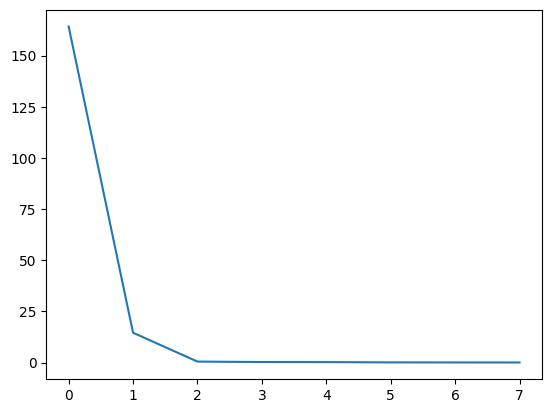

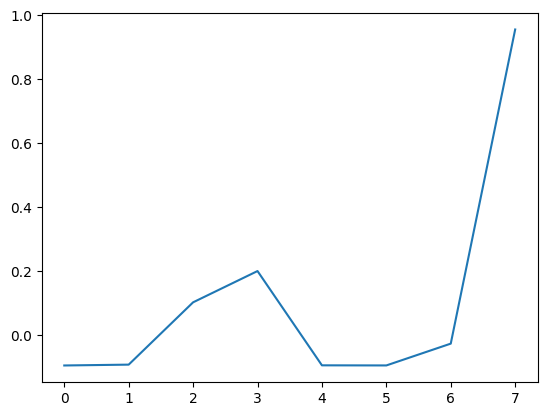

The parameter order is :K, p, mu, Rm, v, T, K_hat, r
GAS_score is [9.18786569e-03 8.68776108e-03 1.03563882e-02 3.98344997e-02
 9.10004094e-03 9.16439180e-03 7.54714430e-04 9.12914338e-01]
K is: 0.009187865686480435
p is: 0.008687761075662973
mu is: 0.010356388186888488
Rm is: 0.039834499677656225
v is: 0.009100040939730696
T is: 0.009164391795901897
K_hat is: 0.0007547144295598851
r is: 0.9129143382081193


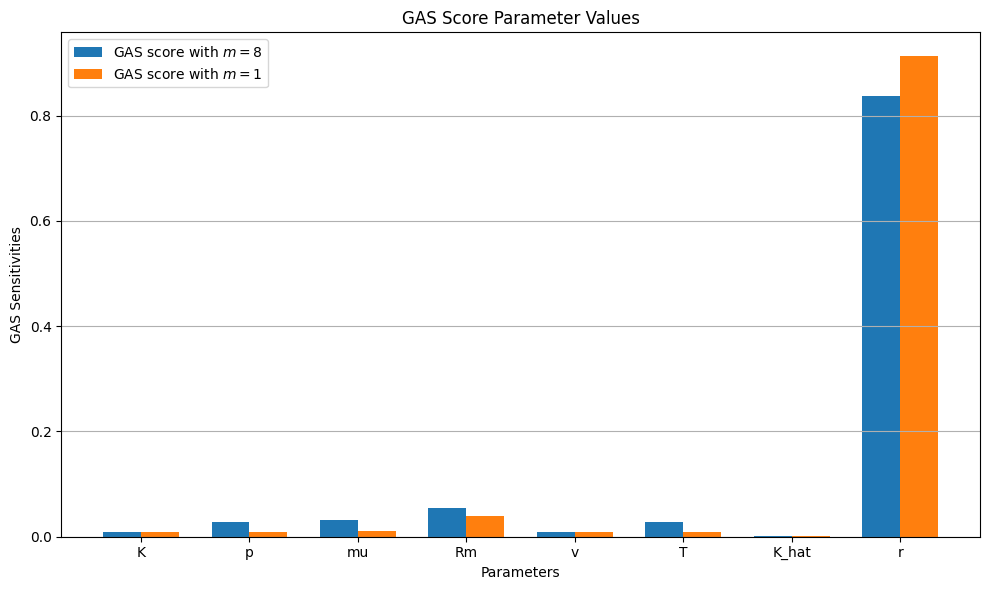

In [ ]:
start = time.perf_counter()
dim=8
chi=10000
M2 = 5
C = calc_C(
            f=Func,
            X=R.uniform(0, 1, (int(chi/2/M2), dim)),
            n_points=M2
        )
#print("55555",C.shape)
#u, s, _ = np.linalg.svd(C.T.astype(float), full_matrices=False)

#gas_values8 = GAS_score(8, u, s)
#gas_values = GAS_score(1, u, s)

C = 0.5 * (C + C.T)                 # 数值对称
s, u = np.linalg.eigh(C)            # s 升序，u 的第 i 列 ↔ s[i]

# 需要降序：
idx = np.argsort(s)[::-1]
s = s[idx]
u = u[:, idx]

# 交给 GAS
gas_values8 = GAS_score(8, u, s)
gas_values  = GAS_score(1, u, s)
end = time.perf_counter()
print("Time:", end - start, "seconds")

plt.plot(s)
plt.show()

plt.plot(u[:,0])
plt.show()

# Print the values
print("The parameter order is :K, p, mu, Rm, v, T, K_hat, r")
print("GAS_score is",gas_values)
print("K is:",gas_values[0])
print("p is:",gas_values[1])
print("mu is:",gas_values[2])
print("Rm is:",gas_values[3])
print("v is:",gas_values[4])
print("T is:",gas_values[5])
print("K_hat is:",gas_values[6])
print("r is:",gas_values[7])


# 参数标签
parameters = ["K", "p", "mu", "Rm", "v", "T", "K_hat", "r"]
x = np.arange(len(parameters))
width = 0.35

# 绘制并排柱状图
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, gas_values8, width, label=r'GAS score with $m=8$')
plt.bar(x + width/2, gas_values, width, label=r'GAS score with $m=1$')

# 设置标签和样式
plt.xlabel("Parameters")
plt.ylabel("GAS Sensitivities")
plt.title("GAS Score Parameter Values")
plt.xticks(x, parameters)
plt.grid(axis='y')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#### GAS gaussian-quad 新版更正代码含带噪音（有错）（测试方程）
from typing import Callable, Optional
from scipy.special import roots_legendre
import numpy as np
import numpy.random as R
import time
from scipy.stats import qmc
from scipy.stats import norm
from scipy.stats import chi2
from scipy import stats
from scipy.integrate import newton_cotes
import random
import math
import matplotlib.pyplot as plt
from numpy.linalg import eig
%matplotlib inline
from scipy.integrate import solve_ivp, simpson

def _gauss_legendre_01(n: int):
    # GL on (0,1): map (-1,1) -> (0,1)
    t, w = roots_legendre(n)
    s = 0.5*(t + 1.0)     # nodes in (0,1)
    w = 0.5*w             # sum to 1
    return s, w

def calc_C(
    f: Callable[[np.ndarray], np.ndarray],
    X: np.ndarray,
    n_points: int = 10,
    g: Optional[Callable[[np.ndarray], np.ndarray]] = None,  # 边缘密度；均匀时可缺省
    return_AS: bool = False,  # 如需调试可顺带返回 A,S
    clip_eps: float = 1e-12   # 数值误差矫正
):
    """
    直接返回“正确的”敏感度矩阵 C（对称 PSD）：
      - 对角: E_z[ ∫ q_i(v;z)^2 dv ]
      - 非对角: E_z[ (∫ q_i dv)(∫ q_j dv) ]
    不增加任何 f 调用；只在同一批节点上额外做了平方与加权。
    """
    M, d = X.shape
    A = np.zeros((M, d), dtype=float)   # A[i,j] = ∫ q_i dv  （非对角用）
    S = np.zeros((M, d), dtype=float)   # S[i,j] = ∫ q_i^2 dv（对角用）

    s_nodes, s_w = _gauss_legendre_01(n_points)
    f_z = f(X)                          # 基点 f(z) 只算一次

    for i in range(M):
        z  = X[i]
        fz = f_z[i]

        for j in range(d):
            zj = z[j]

            # --- 左段 v ∈ [0, z_j],  v = z_j * s  ---
            if zj > 0.0:
                eval_left = np.tile(z, (n_points, 1))
                eval_left[:, j] = zj * s_nodes
                f_left = f(eval_left)                 # 复用：不重复算

                vL = eval_left[:, j]
                qL = (f_left - fz) / (vL - zj)        # q = (f(v)-f(z)) / (v - z_j)

                gL = 1.0 if g is None else g(vL)
                JL = zj                               # dv = z_j ds

                A[i, j] += np.dot(qL,        s_w) * JL * gL
                S[i, j] += np.dot(qL * qL,   s_w) * JL * gL

            # --- 右段 v ∈ [z_j, 1],  v = z_j + (1-z_j) * s ---
            if zj < 1.0:
                eval_right = np.tile(z, (n_points, 1))
                eval_right[:, j] = zj + (1.0 - zj) * s_nodes
                f_right = f(eval_right)

                vR = eval_right[:, j]
                qR = (f_right - fz) / (vR - zj)

                gR = 1.0 if g is None else g(vR)
                JR = (1.0 - zj)

                A[i, j] += np.dot(qR,        s_w) * JR * gR
                S[i, j] += np.dot(qR * qR,   s_w) * JR * gR

    # 组装 C：先用 A^T A / M 放非对角，再用 S 的均值替换对角
    C = (A.T @ A) / M
    np.fill_diagonal(C, S.mean(axis=0))

    # 数值对称化 + 夹小负值到 0（避免舍入误差破坏 PSD）
    C = 0.5 * (C + C.T)
    w, _ = np.linalg.eigh(C)
    if w.min() < -clip_eps:
        # 仅当你特别在意 PSD，可用投影法强制 PSD；默认仅做微小裁剪
        C[np.diag_indices_from(C)] = np.maximum(np.diag(C), 0.0)

    return (C, A, S) if return_AS else C

def dFunc0(x,Func,M2,shiftedSobol=True,distribution='uniform'):    #rememebr to change distribution if not use shiftedSobol
    chi,dim = x.shape[0],x.shape[1]
    temp = np.zeros((dim,chi*M2))
    #print("55555",x)
    if(shiftedSobol == True):
        rand_add = qmc.Sobol(dim, scramble=False).random(M2+1)[1:]
        for i in range(M2):
            xe = np.tile(x.transpose(), dim).transpose()*(1-np.repeat(np.array(np.identity(dim)), chi, axis=0))
            if distribution == 'normal':
                rand = norm.ppf((norm.cdf(x)+rand_add[i])%1)
            elif distribution == 'uniform':
                rand = (x+rand_add[i])%1
            elif distribution =='chi_squared':
                rand1 = chi2.ppf((chi2.cdf(x[:,0],df=10)+rand_add[i][0])%1, df=10)
                rand2 = chi2.ppf((chi2.cdf(x[:,1],df=13.978)+rand_add[i][1])%1, df=13.978)
                rand = np.column_stack((rand1, rand2))
            #print("22222",rand)
            xe += rand.T.reshape(dim*chi,1)*np.repeat(np.array(np.identity(dim)), chi, axis=0)
            #print("11111",xe)
            #xe += rand.T * np.repeat(np.array(np.identity(dim)), chi, axis=0)
            #print("55555",x.shape)
            #print("66666",Func(xe).shape)
            #print("77777",Func(x).shape)
            #print("8888",np.tile(Func(x),dim).shape)
            #print("101010",np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1).reshape(dim,chi))
            temp[:,i*(chi):(i+1)*(chi)] = ((Func(xe)-np.tile(Func(x),dim))/np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1)).reshape(dim,chi)

    else:
        for i in range(M2):
            xe = np.tile(x.transpose(), dim).transpose()*(1-np.repeat(np.array(np.identity(dim)), chi, axis=0))
            if distribution == 'normal':
                rand = R.normal(0,1,(chi,dim))
            elif distribution == 'uniform':
                rand = R.uniform(0,1,(chi,dim))
            xe += rand.T.reshape(dim*chi,1)*np.repeat(np.array(np.identity(dim)), chi, axis=0)
            temp[:,i*(chi):(i+1)*(chi)] = ((Func(xe)-np.tile(Func(x),dim))/np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1)).reshape(dim,chi)

    return temp

# Calculate eigenvalue decomposition //Func in put is m*n matrix, where n is the dimension of x of f(x), m is how many sample to repeat for x 比如100*10 100个x 每个x是10dimension.
#                     output is m number of result f(x)
def GAS(Func,dim,chi,M1,M2,shiftedSobol=True,distribution='uniform'):      #remember to change distribution
    if distribution == 'normal':
        z = R.normal(0, 1, (M1, dim))
    elif distribution == 'uniform':
        z = R.uniform(0, 1, (M1, dim))
        #for i, parameters in enumerate(z):
          #a=solve_and_integrate(parameters,10)
          #while a<28402714.35 or a>276499908.09:
            #z[i] = R.uniform(0, 1, (1, dim))
            #a=solve_and_integrate(parameters,10)
    elif distribution == 'chi_squared':                 #special case for chi_squared
        x1_samples = R.chisquare(df=10, size=M1)
        x2_samples = R.chisquare(df=13.978, size=M1)
        z = np.column_stack((x1_samples, x2_samples))
    deriv = dFunc0(z,Func,M2,shiftedSobol,distribution=distribution)
    deriv /= np.sqrt(chi)
    u, s, vh = np.linalg.svd(deriv.astype(float), full_matrices=True)
    s = s**2
    return u, s



# Estimate the matrix Phi
def Phi_est(X, expo, coef, P):
    Num = X.shape[0]
    dim = X.shape[1]
    return np.dot(np.prod((np.tile(X, P)**expo.flatten()).reshape((Num*P, dim)),axis = 1).reshape((Num, P))
               ,np.array(coef)).T

def Funy(z,z1,u,Func):
    dim = u.shape[0]
    dim1 = z.shape[1]
    chi = z.shape[0]
    f1 = Func(np.dot(z,u[:,:dim1].transpose())+np.dot(z1,u[:,dim1:].transpose()))
    return f1

# Estimate k hat
def estimate_k_reg1(z,z1,u, exponents, coefficients, P, Func):
    phi = Phi_est(z, exponents, coefficients,P)
    khat = np.linalg.inv(phi @ np.transpose(phi)) @ phi @ Funy(z,z1,u,Func)
    return khat

# Estimate the expectation from PCE
def GAS_PCE(Func, Num_exp, z1, dim1, u, exponents, coefficients, P):
    PCE = np.zeros(Num_exp)
    for i in range(Num_exp):
        kii = estimate_k_reg1(z1[i][:,:dim1], z1[i][:,dim1:], u, exponents, coefficients, P, Func)
        PCE[i] = kii[0]
    return PCE

def GAS_score(m,u,s):                         #m is how many eigenvalue we use
  gas_score = u[:,:m]**2@s[:m]/sum(u[:,:m]**2@s[:m])
  return gas_score

def solve_and_integrate(parameters,n):
    K, p, mu, Rm, v, T, K_hat, r= parameters
    K=K*(1.3-0.7)*3.5+0.7*3.5
    p=p*(1.3-0.7)*2+0.7*2
    mu=mu*(1.3-0.7)*0.5+0.7*0.5
    Rm=Rm*(1.3-0.7)*1+0.7*1
    v=v*(1.3-0.7)*1+0.7*1
    T=T*(1.3-0.7)*5+0.7*5
    K_hat=K_hat*(1.3-0.7)*43+0.7*43
    r=r*(1.3-0.7)*0.7+0.7*0.7


    # Define the ODE systems
    #def ode_system_1(t, B):
        #return K * p / (mu * (Rm + v * B))

    #def ode_system_2(t, B):
        #return -K_hat * p * B / (mu * (Rm + v * B))

    # Define the ODE systems
    def ode_system_1(t, B):
        val=(K * p / (mu * (Rm + v * B)))
        return val + np.random.normal(loc=0, scale=abs(val)*0.2)                      ## add noisy with N(0,#% of answer)
    def ode_system_2(t, B):
        val=(-K_hat * p * B / (mu * (Rm + v * B)))
        return val + np.random.normal(loc=0, scale=abs(val)*0.2)                      ## add noisy with N(0,#% of answer)


    # Initialize
    B0 = 0.0  # Initial condition for B
    total_integrand_values = []
    total_time_points = []
    B_values = []  # Store B values over time

    # Interval length
    interval_length = T / n

    for i in range(n):
        # Time spans for the current interval
        t1_span = (i * interval_length, i * interval_length + r * interval_length)
        t2_span = (i * interval_length + r * interval_length, (i + 1) * interval_length)

        # Solve first ODE in the current interval
        t1_eval = np.linspace(t1_span[0], t1_span[1], 50)
        solution_1 = solve_ivp(ode_system_1, t1_span, [B0], t_eval=t1_eval, method='RK45')
        t1 = solution_1.t
        B1 = solution_1.y[0]

        # Solve second ODE in the current interval
        B1_final = B1[-1]  # Final value of B from the first ODE
        t2_eval = np.linspace(t2_span[0], t2_span[1], 50)
        solution_2 = solve_ivp(ode_system_2, t2_span, [B1_final], t_eval=t2_eval, method='RK45')
        t2 = solution_2.t
        B2 = solution_2.y[0]

        # Combine time and B values for this interval
        t_combined = np.concatenate((t1, t2))
        B_combined = np.concatenate((B1, B2))

        # Update the initial condition for the next interval using the final state of B2
        B0 = B2[-1]

        # Store results
        total_time_points.extend(t_combined)
        B_values.extend(B_combined)

        # Compute the integrand values
        integrand_1 = p / (mu * (Rm + v * np.array(B1)))  # First part
        integrand_2 = -p / (mu * (Rm + v * np.array(B2))) # Second part (negative)

        total_integrand_values.extend(integrand_1)
        total_integrand_values.extend(integrand_2)

    # Compute the final integral
    integral_simps = simpson(total_integrand_values, x=total_time_points)

    # Compute cumulative integral approximation
    cumulative_integral = np.cumsum(np.array(total_integrand_values) * np.gradient(total_time_points))

    return cumulative_integral[-1]

def percentage_within_std_range(numbers, std_range=1):
    mean_val = np.mean(numbers)  # Compute the mean
    std_dev = np.std(numbers, ddof=1)  # Compute standard deviation

    # Define the statistical range
    lower_bound = mean_val - std_range * std_dev
    upper_bound = mean_val + std_range * std_dev

    # Count numbers within the range
    within_range = [num for num in numbers if lower_bound <= num <= upper_bound]
    percentage_within = (len(within_range) / len(numbers)) * 100

    return {
        "mean": mean_val,
        "std_dev": std_dev,
        "range": (lower_bound, upper_bound),
        "percentage_within": percentage_within,
        "total_values": len(numbers),
        "values_within_range": len(within_range)
    }

def Func(x):                                  #example 2
  x=x-0.5
  # Summation of i * x_i for i in range 1 to 10
  summation = sum(i * x[:,i-1] for i in range(1, 11))

  # Interaction term
  interaction = 10 * (x[:,0] * x[:,1] - x[:,8] * x[:,9])

  # Noise term from N(0, 1)
  noise = 1*R.normal(0,1,x.shape[0])
  # Final result
  return summation + interaction + noise


55555 (10, 10)
Time: 6.399748430999921 seconds


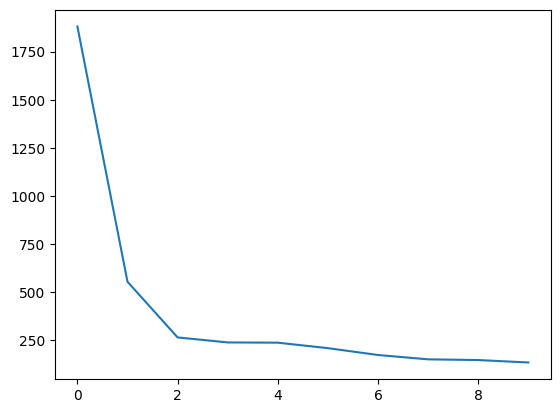

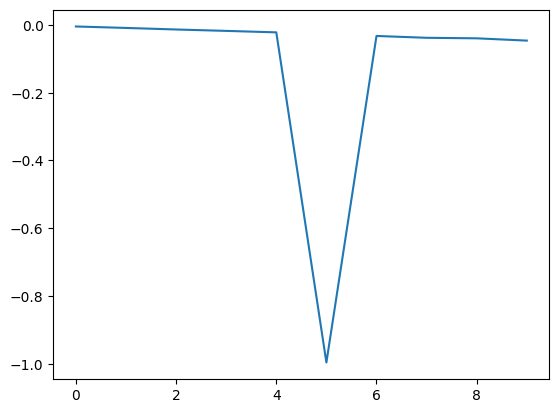

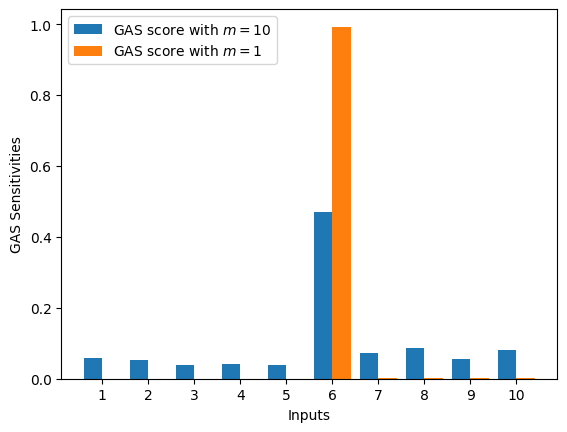

1.0


In [ ]:
start = time.perf_counter()
dim=10
chi=10000
M2 = 1
C = calc_C(
            f=Func,
            X=R.uniform(0, 1, (int(chi/2/M2), dim)),
            n_points=M2
        )
print("55555",C.shape)
#u, s, _ = np.linalg.svd(C.T.astype(float), full_matrices=False)

#gas_values8 = GAS_score(8, u, s)
#gas_values = GAS_score(1, u, s)

C = 0.5 * (C + C.T)                 # 数值对称
s, u = np.linalg.eigh(C)            # s 升序，u 的第 i 列 ↔ s[i]

# 需要降序：
idx = np.argsort(s)[::-1]
s = s[idx]
u = u[:, idx]

# 交给 GAS
gas_values8 = GAS_score(10, u, s)
gas_values  = GAS_score(1, u, s)
end = time.perf_counter()
print("Time:", end - start, "seconds")

plt.plot(s)
plt.show()

plt.plot(u[:,0])
plt.show()

width = 0.4
x = np.arange(1,dim+1)
labels = x
fig, ax4 = plt.subplots()
rects1 = ax4.bar(x-width/2, GAS_score(10,u,s), width, label='GAS score with $m = 10$')
rects2 = ax4.bar(x+width/2, GAS_score(1,u,s), width, label='GAS score with $m = 1$')
ax4.set_ylabel('GAS Sensitivities')
ax4.set_xlabel('Inputs')
ax4.set_xticks(x)
ax4.set_xticklabels(labels)
# Add a legend
ax4.legend()
# Show the plot
plt.show()

print(sum(GAS_score(10,u,s)))

In [ ]:
#### GAS gaussian-quad 新版更正代码含带噪音（有错）（测试方程）
from typing import Callable, Optional
from scipy.special import roots_legendre
import numpy as np
import numpy.random as R
import time
from scipy.stats import qmc
from scipy.stats import norm
from scipy.stats import chi2
from scipy import stats
from scipy.integrate import newton_cotes
import random
import math
import matplotlib.pyplot as plt
from numpy.linalg import eig
%matplotlib inline
from scipy.integrate import solve_ivp, simpson

def _gauss_legendre_01(n: int):
    # GL on (0,1): map (-1,1) -> (0,1)
    t, w = roots_legendre(n)
    s = 0.5*(t + 1.0)     # nodes in (0,1)
    w = 0.5*w             # sum to 1
    return s, w

def calc_C_normal(
    f: Callable[[np.ndarray], np.ndarray],
    X: np.ndarray,
    n_points: int = 10,
    return_AS: bool = False,
    clip_eps: float = 1e-12
):
    """
    C matrix for iid N(0,1) inputs.
    Uses change of variable u = Phi(v), v = Phi^{-1}(u),
    so the integral is still over (0,1).
    """
    M, d = X.shape
    A = np.zeros((M, d), dtype=float)
    S = np.zeros((M, d), dtype=float)

    s_nodes, s_w = _gauss_legendre_01(n_points)
    f_z = f(X)

    for i in range(M):
        z = X[i]
        fz = f_z[i]

        for j in range(d):
            zj = z[j]
            uj = norm.cdf(zj)

            # --- left part: u in [0, uj] ---
            if uj > 0.0:
                u_left = uj * s_nodes
                v_left = norm.ppf(u_left)

                eval_left = np.tile(z, (n_points, 1))
                eval_left[:, j] = v_left
                f_left = f(eval_left)

                qL = (f_left - fz) / (v_left - zj)
                JL = uj   # du = uj ds

                A[i, j] += np.dot(qL, s_w) * JL
                S[i, j] += np.dot(qL * qL, s_w) * JL

            # --- right part: u in [uj, 1] ---
            if uj < 1.0:
                u_right = uj + (1.0 - uj) * s_nodes
                v_right = norm.ppf(u_right)

                eval_right = np.tile(z, (n_points, 1))
                eval_right[:, j] = v_right
                f_right = f(eval_right)

                qR = (f_right - fz) / (v_right - zj)
                JR = 1.0 - uj

                A[i, j] += np.dot(qR, s_w) * JR
                S[i, j] += np.dot(qR * qR, s_w) * JR

    C = (A.T @ A) / M
    np.fill_diagonal(C, S.mean(axis=0))

    C = 0.5 * (C + C.T)
    w, _ = np.linalg.eigh(C)
    if w.min() < -clip_eps:
        C[np.diag_indices_from(C)] = np.maximum(np.diag(C), 0.0)

    return (C, A, S) if return_AS else C

def calc_C(
    f: Callable[[np.ndarray], np.ndarray],
    X: np.ndarray,
    n_points: int = 10,
    g: Optional[Callable[[np.ndarray], np.ndarray]] = None,  # 边缘密度；均匀时可缺省
    return_AS: bool = False,  # 如需调试可顺带返回 A,S
    clip_eps: float = 1e-12   # 数值误差矫正
):
    """
    直接返回“正确的”敏感度矩阵 C（对称 PSD）：
      - 对角: E_z[ ∫ q_i(v;z)^2 dv ]
      - 非对角: E_z[ (∫ q_i dv)(∫ q_j dv) ]
    不增加任何 f 调用；只在同一批节点上额外做了平方与加权。
    """
    M, d = X.shape
    A = np.zeros((M, d), dtype=float)   # A[i,j] = ∫ q_i dv  （非对角用）
    S = np.zeros((M, d), dtype=float)   # S[i,j] = ∫ q_i^2 dv（对角用）

    s_nodes, s_w = _gauss_legendre_01(n_points)
    f_z = f(X)                          # 基点 f(z) 只算一次

    for i in range(M):
        z  = X[i]
        fz = f_z[i]

        for j in range(d):
            zj = z[j]

            # --- 左段 v ∈ [0, z_j],  v = z_j * s  ---
            if zj > 0.0:
                eval_left = np.tile(z, (n_points, 1))
                eval_left[:, j] = zj * s_nodes
                f_left = f(eval_left)                 # 复用：不重复算

                vL = eval_left[:, j]
                qL = (f_left - fz) / (vL - zj)        # q = (f(v)-f(z)) / (v - z_j)

                gL = 1.0 if g is None else g(vL)
                JL = zj                               # dv = z_j ds

                A[i, j] += np.dot(qL,        s_w) * JL * gL
                S[i, j] += np.dot(qL * qL,   s_w) * JL * gL

            # --- 右段 v ∈ [z_j, 1],  v = z_j + (1-z_j) * s ---
            if zj < 1.0:
                eval_right = np.tile(z, (n_points, 1))
                eval_right[:, j] = zj + (1.0 - zj) * s_nodes
                f_right = f(eval_right)

                vR = eval_right[:, j]
                qR = (f_right - fz) / (vR - zj)

                gR = 1.0 if g is None else g(vR)
                JR = (1.0 - zj)

                A[i, j] += np.dot(qR,        s_w) * JR * gR
                S[i, j] += np.dot(qR * qR,   s_w) * JR * gR

    # 组装 C：先用 A^T A / M 放非对角，再用 S 的均值替换对角
    C = (A.T @ A) / M
    np.fill_diagonal(C, S.mean(axis=0))

    # 数值对称化 + 夹小负值到 0（避免舍入误差破坏 PSD）
    C = 0.5 * (C + C.T)
    w, _ = np.linalg.eigh(C)
    if w.min() < -clip_eps:
        # 仅当你特别在意 PSD，可用投影法强制 PSD；默认仅做微小裁剪
        C[np.diag_indices_from(C)] = np.maximum(np.diag(C), 0.0)

    return (C, A, S) if return_AS else C

def GAS_score(m,u,s):                         #m is how many eigenvalue we use
  gas_score = u[:,:m]**2@s[:m]/sum(u[:,:m]**2@s[:m])
  return gas_score


def Func(x):
    # example 1
    result = np.exp(0.8 * x[:, 0] + 0.6 * x[:, 1]) + 0.001 * x[:, 2]
    return result


In [ ]:
dim = 3
chi = 20000
M2 = 5

X = R.normal(0, 1, (int(chi / 2 / M2), dim))

C = calc_C_normal(
    f=Func,
    X=X,
    n_points=M2
)

print("55555", C.shape)

C = 0.5 * (C + C.T)
s, u = np.linalg.eigh(C)

idx = np.argsort(s)[::-1]
s = s[idx]
u = u[:, idx]

print(s)
print(u)

55555 (3, 3)
[4.20498505e+00 4.33967536e-01 4.63958578e-07]
[[-7.73529746e-01 -6.33759927e-01 -2.94613385e-04]
 [-6.33759895e-01  7.73529802e-01 -2.03585456e-04]
 [-3.56916537e-04 -2.92347410e-05  9.99999936e-01]]
